In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer

In [2]:
#import warnings
#warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/olist_rfm.csv')

In [4]:
df.head()

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90


In [5]:
# remove customer_unique_id
df.drop(['customer_unique_id'], axis=1, inplace=True)
df.head()

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90


In [6]:
df.head()

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90


In [7]:
df.shape

(96096, 3)

In [8]:
df.dtypes

recency        int64
frequency      int64
monetary     float64
dtype: object

In [9]:
df.isna().sum()

recency      0
frequency    0
monetary     0
dtype: int64

In [10]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,frequency,monetary
0.25,164.0,1.0,45.99
0.50,269.0,1.0,89.00
0.75,397.0,1.0,154.00


# Distribution

<AxesSubplot:xlabel='monetary', ylabel='Count'>

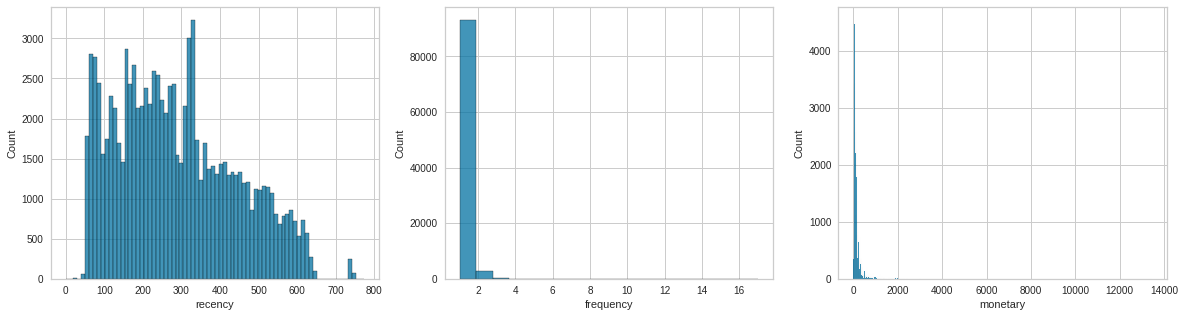

In [11]:
#Plot data distribution
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(df['recency'])

plt.subplot(1,3,2)
sns.histplot(df['frequency'])

plt.subplot(1,3,3)
sns.histplot(df['monetary'])

In [12]:
#apply log transformation 
rfm_log = df[['recency', 'frequency', 'monetary']].apply(np.log, axis=1).round(3)

In [13]:
rfm_log.head()

,recency,frequency,monetary
0,5.940,0.693,4.180
1,4.443,0.000,4.777
2,4.248,0.000,5.075
3,5.808,0.000,3.807
4,5.505,0.000,2.991


<AxesSubplot:xlabel='monetary', ylabel='Count'>

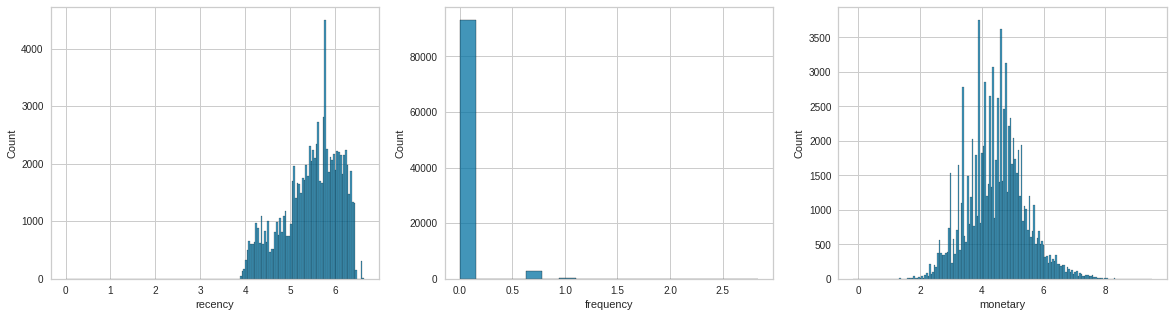

In [14]:
#Plot data distribution after log transformation
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(rfm_log['recency'])

plt.subplot(1,3,2)
sns.histplot(rfm_log['frequency'])

plt.subplot(1,3,3)
sns.histplot(rfm_log['monetary'])

# Echantillon

In [15]:
#df_redux = df.sample(10000, random_state=1).copy()
#X = df_redux.copy()
X= df.copy() ## consomme de la mémoire
#categorical_columns = X.select_dtypes(['category','object']).columns
numerical_columns = X.select_dtypes(['int64','float64']).columns
ss = StandardScaler()
X[numerical_columns] = ss.fit_transform(X[numerical_columns])

In [16]:
X.head()

,recency,frequency,monetary
0,0.598963,4.502189,-0.350152
1,-1.323900,-0.162368,-0.104681
2,-1.421672,-0.162368,0.084993
3,0.292609,-0.162368,-0.443976
4,-0.274473,-0.162368,-0.559530


In [17]:
X.shape

(96096, 3)

In [18]:
df

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90
...,...,...,...
96091,587,1,72.00
96092,253,1,174.90
96093,416,1,205.99
96094,282,1,359.98


# PCA

In [19]:
pca = PCA()

In [20]:
pca.fit(X)

PCA()

In [21]:
X.shape

(96096, 3)

In [22]:
# ajouter float point to plot

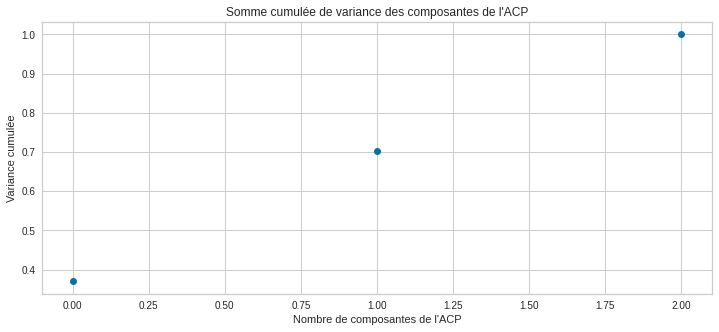

In [23]:
plt.figure(figsize=(12,5))
plt.title('Somme cumulée de variance des composantes de l\'ACP')
plt.xlabel('Nombre de composantes de l\'ACP')
plt.ylabel('Variance cumulée')
plt.plot(list(range(X.shape[1])),
         np.cumsum(pca.explained_variance_ratio_), 'o')

In [24]:
np.cumsum(pca.explained_variance_ratio_)[1]

0.7029684098506765

In [25]:
np.cumsum(pca.explained_variance_ratio_)[2]

1.0

In [26]:
colonnes_pca = X.columns

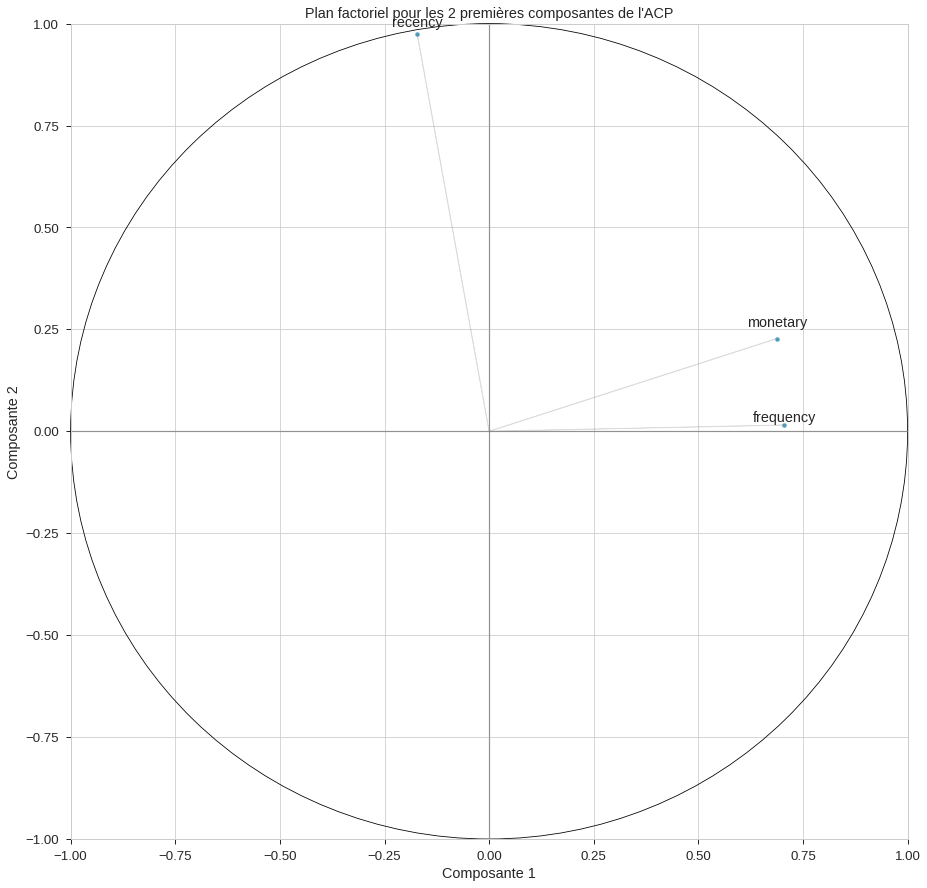

In [27]:
from matplotlib.patches import Circle
sns.set_context("paper", font_scale=1.5) 
plt.figure(figsize=(15,15))
chaine = "Plan factoriel pour les 2 premières composantes de l'ACP"
plt.title(chaine)
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
ax = plt.gca()
ax.add_patch(Circle([0,0], radius=1, color='black', fill=False, linestyle='-', 
                    clip_on=False))
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
x_pca = pca.components_[0,:]
y_pca = pca.components_[1,:]

sns.scatterplot(x = x_pca,
                y = y_pca,
               alpha = 0.7)
plt.plot([-1,1],[0,0], color='grey', alpha=0.8)
plt.plot([0,0],[-1,1], color='grey', alpha=0.8)

i = 0
for x,y,colonne in zip(x_pca,y_pca, colonnes_pca):

    plt.annotate(colonne, 
                 (x,y), 
                 textcoords="offset points", 
                 xytext=(0,5+np.random.randint(-10,10)),
                 ha='center') 
    ax.arrow(0, 0, x, y, head_width=0, head_length=0, fc='grey', ec='grey',
             alpha=0.2)


sns.set_context("paper", font_scale=1) 

# T-SNE

In [28]:
tsne = TSNE(n_components=2)
T = tsne.fit_transform(X.copy())
# appliquer labels via dataframe (labels de dict kmeans)

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:title={'center':'Représentation des données via T-SNE'}>

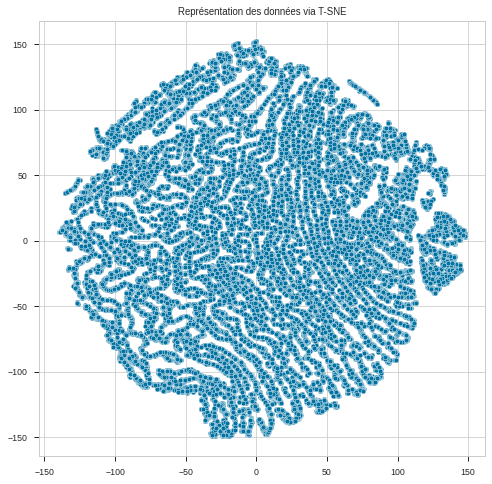

In [29]:
plt.figure(figsize=(8,8))
plt.title('Représentation des données via T-SNE')
sns.scatterplot(T[:,0], T[:,1])
# boucle 3 scatterplots selon label

# K-Means

In [30]:
# print avancement au fur et à mesure

In [32]:
kmeans = KMeans(n_clusters=5, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X)

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee5fb820>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 

Initialization complete
Iteration 0, inertia 91009.18366672176.
Iteration 1, inertia 81907.25496144156.
Iteration 2, inertia 81390.28767898108.
Iteration 3, inertia 81209.407010869.
Iteration 4, inertia 81147.7181579007.
Iteration 5, inertia 81113.61113584964.
Iteration 6, inertia 81078.21858837834.
Iteration 7, inertia 80976.17650206166.
Iteration 8, inertia 80841.29924439752.
Iteration 9, inertia 80778.3571407476.
Iteration 10, inertia 80740.42562777967.
Iteration 11, inertia 80721.68468438217.
Converged at iteration 11: center shift 7.992182389464443e-05 within tolerance 9.999999999988223e-05.
Initialization complete

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee8e8940>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling cty


Iteration 0, inertia 102369.11575433565.
Iteration 1, inertia 83189.464468773.
Iteration 2, inertia 81442.12041582703.
Iteration 3, inertia 80925.05816847555.
Iteration 4, inertia 80719.85520734763.
Iteration 5, inertia 80629.27995427106.
Iteration 6, inertia 80580.10107126695.
Iteration 7, inertia 80551.48366506172.
Iteration 8, inertia 80531.31485064076.
Iteration 9, inertia 80521.46989741159.
Iteration 10, inertia 80516.75162978917.
Converged at iteration 10: center shift 3.490935504992692e-05 within tolerance 9.999999999988223e-05.
Initialization complete


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdf2ae3a60>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Iteration 0, inertia 121638.03198649017.
Iteration 1, inertia 88697.98608592268.
Iteration 2, inertia 83194.15149843182.
Iteration 3, inertia 81330.13157599958.
Iteration 4, inertia 80859.347036491.
Iteration 5, inertia 80777.34304911175.
Iteration 6, inertia 80741.1831196015.
Iteration 7, inertia 80721.82201279848.
Iteration 8, inertia 80717.20007276387.
Iteration 9, inertia 80716.10107805967.
Converged at iteration 9: center shift 8.544573134510448e-05 within tolerance 9.999999999988223e-05.
Initialization complete
Iteration 0, inertia 91393.52209241518.


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17f93160>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Iteration 1, inertia 81369.18091823948.
Iteration 2, inertia 81172.43291464951.
Iteration 3, inertia 81074.23000606264.
Iteration 4, inertia 81049.51612554665.
Iteration 5, inertia 80993.29103908243.
Iteration 6, inertia 80871.50271102587.
Iteration 7, inertia 80768.65240780238.
Iteration 8, inertia 80715.38347739981.
Iteration 9, inertia 80690.21954871231.
Iteration 10, inertia 80683.89687344947.
Converged at iteration 10: center shift 4.073417611677924e-05 within tolerance 9.999999999988223e-05.
Initialization complete
Iteration 0, inertia 100029.71870169911.
Iteration 1, inertia 84413.22080268964.
Iteration 2, inertia 82562.26507265678.
Iteration 3, inertia 81915.88392046311.
Iteration 4, inertia 81573.10301058454.
Iteration 5, inertia 81367.25056046197.
Iteration 6, inertia 81247.65918480334.
Iteration 7, inertia 81186.07636617695.
Iteration 8, inertia 81104.38401084971.
Iteration 9, inertia 80975.093061242.
Iteration 10, inertia 80880.62595673183.
Iteration 11, inertia 80826.32251

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee8e8310>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Initialization complete
Iteration 0, inertia 119789.53697831614.
Iteration 1, inertia 87899.11546398954.
Iteration 2, inertia 84314.03342253827.
Iteration 3, inertia 82832.4815798408.
Iteration 4, inertia 82034.6669234893.
Iteration 5, inertia 81568.41285971584.
Iteration 6, inertia 81244.87178361739.
Iteration 7, inertia 81056.14728735421.
Iteration 8, inertia 80909.02883162747.
Iteration 9, inertia 80846.36882136669.
Iteration 10, inertia 80816.07838565164.
Iteration 11, inertia 80802.99913350967.
Iteration 12, inertia 80793.84713885853.
Iteration 13, inertia 80783.13410781896.
Iteration 14, inertia 80748.64234138634.
Iteration 15, inertia 80703.97156424331.
Iteration 16, inertia 80691.61180091857.
Iteration 17, inertia 80687.38822138023.
Iteration 18, inertia 80684.41711489088.
Iteration 19, inertia 80682.12090475365.
Iteration 20, inertia 80681.15575224067.
Iteration 21, inertia 80680.73410550729.
Converged at iteration 21: center shift 1.4179763181920371e-05 within tolerance 9.999

In [33]:
kmeans.labels_

array([3, 0, 0, ..., 1, 4, 4], dtype=int32)

In [34]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [36]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e630d0>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 

1
Initialization complete
Iteration 0, inertia 321894.99527316814.
Iteration 1, inertia 288288.0000000001.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 743601.2671264183.
Iteration 1, inertia 288288.0000000001.
Converged at iteration 1: strict convergence.
Initialization complete


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e630d0>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Iteration 0, inertia 433687.28381031164.
Iteration 1, inertia 288288.0000000001.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 443456.2942623302.
Iteration 1, inertia 288288.0000000001.
Converged at iteration 1: strict convergence.


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee8e8310>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling cty

...

Initialization complete
Iteration 0, inertia 21546.608419307806.
Iteration 1, inertia 17465.491437330926.
Iteration 2, inertia 16897.512439871156.
Iteration 3, inertia 16657.71821842137.
Iteration 4, inertia 16542.964909224473.
Iteration 5, inertia 16488.98714500667.
Iteration 6, inertia 16456.10144578885.
Iteration 7, inertia 16429.447691308535.
Iteration 8, inertia 16408.76475396347.
Iteration 9, inertia 16391.333291039227.
Iteration 10, inertia 16374.007130560929.
Iteration 11, inertia 16359.035387891341.
Iteration 12, inertia 16343.112556578268.
Iteration 13, inertia 16318.725935488512.
Iteration 14, inertia 16296.683088447806.
Iteration 15, inertia 16285.302062750641.
Iteration 16, inertia 16280.15294146236.
Iteration 17, inertia 16277.48050415298.
Iteration 18, inertia 16275.632971958603.
Iteration 19, inertia 16273.43528129215.
Iteration 20, inertia 16271.436192608035.
Iteration 21, inertia 16269.467045372774.
Iteration 22, inertia 16266.675097239851.
Iteration 23, inertia 16263

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e63ee0>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Initialization complete
Iteration 0, inertia 21199.977083459835.
Iteration 1, inertia 18405.565390632004.
Iteration 2, inertia 17915.38817622002.
Iteration 3, inertia 17673.762226444996.
Iteration 4, inertia 17454.529034328225.
Iteration 5, inertia 17272.300731202697.
Iteration 6, inertia 17093.892178536255.
Iteration 7, inertia 16955.931054160443.
Iteration 8, inertia 16851.31695389388.
Iteration 9, inertia 16787.991868236342.
Iteration 10, inertia 16753.78497270313.
Iteration 11, inertia 16734.09468315504.
Iteration 12, inertia 16722.096381354935.
Iteration 13, inertia 16714.271006646108.
Iteration 14, inertia 16709.349690206196.
Iteration 15, inertia 16706.014947892898.
Iteration 16, inertia 16704.34998088637.
Iteration 17, inertia 16703.365040125595.
Converged at iteration 17: center shift 6.942567959328801e-05 within tolerance 9.999999999988223e-05.


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e63d30>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Initialization complete
Iteration 0, inertia 21607.62457595772.
Iteration 1, inertia 17604.36748139.
Iteration 2, inertia 17079.481612271076.
Iteration 3, inertia 16827.176633473075.
Iteration 4, inertia 16661.160953560164.
Iteration 5, inertia 16530.876873693727.
Iteration 6, inertia 16412.024047984043.
Iteration 7, inertia 16308.57037511189.
Iteration 8, inertia 16231.475696006817.
Iteration 9, inertia 16182.270632211419.
Iteration 10, inertia 16152.53550050311.
Iteration 11, inertia 16131.785425157375.
Iteration 12, inertia 16112.553956325652.
Iteration 13, inertia 16096.813985615665.
Iteration 14, inertia 16083.246325469092.
Iteration 15, inertia 16073.261975134286.
Iteration 16, inertia 16065.47830312984.
Iteration 17, inertia 16059.938915720522.
Iteration 18, inertia 16055.837773401667.
Iteration 19, inertia 16052.35010495933.
Iteration 20, inertia 16048.940237200077.
Iteration 21, inertia 16046.335444819528.
Iteration 22, inertia 16044.128807631514.
Iteration 23, inertia 16042.4

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

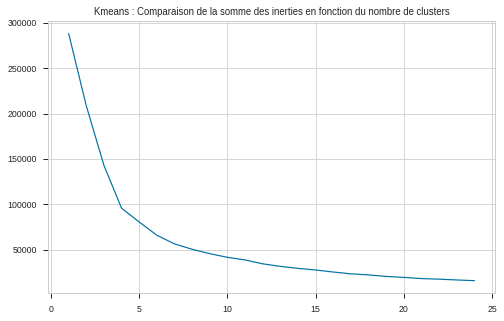

In [37]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [38]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e639d0>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 

Boucle  1
Initialization complete
Iteration 0, inertia 301911.66477530333.
Iteration 1, inertia 288288.00000000006.
Converged at iteration 1: strict convergence.
Initialization complete


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e10670>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Iteration 0, inertia 487880.40375171596.
Iteration 1, inertia 288288.00000000006.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 313509.6705694851.
Iteration 1, inertia 288288.0000000001.
Converged at iteration 1: strict convergence.


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e639d0>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling cty

...

Initialization complete
Iteration 0, inertia 19297.616479823886.
Iteration 1, inertia 16915.060800967494.
Iteration 2, inertia 16436.160294313042.
Iteration 3, inertia 16231.599971129877.
Iteration 4, inertia 16131.11669840449.
Iteration 5, inertia 16082.108988923272.
Iteration 6, inertia 16044.197373100014.
Iteration 7, inertia 16012.200083370933.
Iteration 8, inertia 15991.096553392772.
Iteration 9, inertia 15973.44491629938.
Iteration 10, inertia 15961.026234927838.
Iteration 11, inertia 15949.293635244692.
Iteration 12, inertia 15936.429702068865.
Iteration 13, inertia 15919.076605288308.
Iteration 14, inertia 15902.17276920291.
Iteration 15, inertia 15888.20688556113.
Iteration 16, inertia 15875.571110905974.
Iteration 17, inertia 15865.06401816645.
Iteration 18, inertia 15857.62230178727.
Iteration 19, inertia 15852.610518424068.
Iteration 20, inertia 15848.859415036823.
Iteration 21, inertia 15845.540604251259.
Iteration 22, inertia 15842.41248564276.
Iteration 23, inertia 15839

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e50310>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Iteration 27, inertia 15830.645164850717.
Iteration 28, inertia 15828.903784569717.
Iteration 29, inertia 15827.244443882444.
Iteration 30, inertia 15825.602008708938.
Iteration 31, inertia 15823.801939705229.
Iteration 32, inertia 15822.141390448047.
Iteration 33, inertia 15820.799528613656.
Iteration 34, inertia 15819.676272783088.
Iteration 35, inertia 15818.77424205179.
Converged at iteration 35: center shift 6.345213109922628e-05 within tolerance 9.999999999988223e-05.
Initialization complete
Iteration 0, inertia 21134.303987546507.
Iteration 1, inertia 17797.266473595988.
Iteration 2, inertia 17035.983325111927.
Iteration 3, inertia 16700.151374861154.
Iteration 4, inertia 16535.22302789187.
Iteration 5, inertia 16436.985346346883.
Iteration 6, inertia 16382.031559587396.
Iteration 7, inertia 16345.20978920372.
Iteration 8, inertia 16316.384844088358.
Iteration 9, inertia 16299.789913115179.
Iteration 10, inertia 16286.899991016413.
Iteration 11, inertia 16276.026689644576.
Itera

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17e50310>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Initialization complete
Iteration 0, inertia 20193.658086236264.
Iteration 1, inertia 17499.882211676148.
Iteration 2, inertia 16770.879442554247.
Iteration 3, inertia 16456.109590429107.
Iteration 4, inertia 16267.927001868742.
Iteration 5, inertia 16121.957150667176.
Iteration 6, inertia 16012.51513656765.
Iteration 7, inertia 15944.755995311838.
Iteration 8, inertia 15897.95547161981.
Iteration 9, inertia 15868.801721324258.
Iteration 10, inertia 15846.935412500527.
Iteration 11, inertia 15832.215595752428.
Iteration 12, inertia 15821.706221291593.
Iteration 13, inertia 15815.626274843009.
Iteration 14, inertia 15811.949570082432.
Iteration 15, inertia 15809.675711979626.
Iteration 16, inertia 15807.97377459625.
Iteration 17, inertia 15806.45283802965.
Iteration 18, inertia 15804.701666970235.
Iteration 19, inertia 15802.938740526113.
Iteration 20, inertia 15800.63459790301.
Iteration 21, inertia 15798.160609074406.
Iteration 22, inertia 15795.735125895842.
Iteration 23, inertia 157

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explic

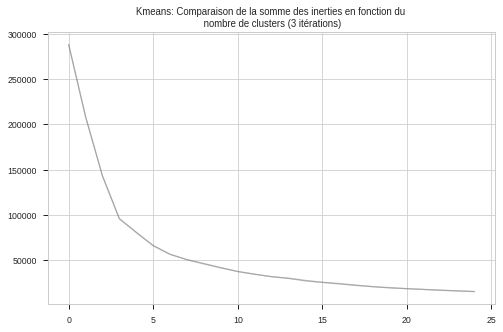

In [39]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [42]:
silhouettes_kmeans = {}
max_clusters = 4
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X,
                                             labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

0.7340508301448087
0.4583095775330445


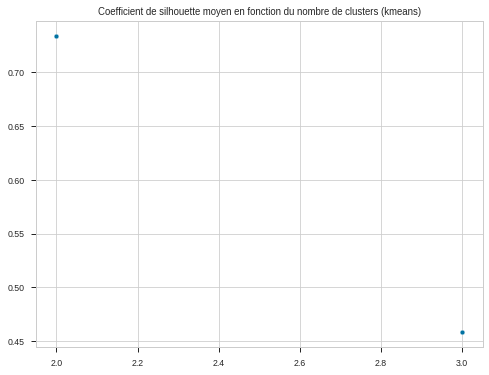

In [43]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [44]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

le coefficient de silhouette est maximal pour 2 clusters (score = 0.7340508301448087)


In [45]:
nb_clusters

2

In [ ]:
## ne pas utiliser inertia juste silhouette silhouette score

In [ ]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [ ]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

In [ ]:
km.labels_

In [ ]:
# kmeans sur toutes les variables

# DBscan

In [46]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X.copy())

NameError: name 'DBSCAN' is not defined

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(T[:,0], T[:,1], dbs.labels_)

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [47]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [48]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

NameError: name 'x_show' is not defined

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement